In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../Dataset/Bengaluru_House_Data.csv")
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [2]:
df.shape

(13320, 9)

In [3]:
df.info(_)

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 1.6 MB


In [4]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

## Phase 3: Data Preprocessing
We will clean the data in this order:
1. Drop low-value columns
2. Handle missing values
3. Clean the messy `total_sqft` column
4. Standardize the `size` column

In [5]:
df1 = df.drop(['area_type', 'society', 'availability'], axis=1)
df1.head()

,location,size,total_sqft,bath,balcony,price
0,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,3.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00
4,Kothanur,2 BHK,1200,2.0,1.0,51.00


In [6]:
df1['total_sqft'].unique()

<ArrowStringArray>
[       '1056',        '2600',        '1440',        '1521',        '1200',
        '1170',        '2732',        '3300',        '1310',        '1020',
 ...
        '3124',        '9200',         '613',         '250',        '2395',
 '1020 - 1130',        '2758', '1133 - 1384',         '774',        '4689']
Length: 2117, dtype: str

In [7]:
def is_float(x):
    try:
        float(x)
        return True
    except:
        return False

df1[~df1['total_sqft'].apply(is_float)].head(15)

,location,size,total_sqft,bath,balcony,price
30,Yelahanka,4 BHK,2100 - 2850,4.0,0.0,186.000
56,Devanahalli,4 Bedroom,3010 - 3410,NaN,NaN,192.000
81,Hennur Road,4 Bedroom,2957 - 3450,NaN,NaN,224.500
122,Hebbal,4 BHK,3067 - 8156,4.0,0.0,477.000
137,8th Phase JP Nagar,2 BHK,1042 - 1105,2.0,0.0,54.005
165,Sarjapur,2 BHK,1145 - 1340,2.0,0.0,43.490
188,KR Puram,2 BHK,1015 - 1540,2.0,0.0,56.800
224,Devanahalli,3 BHK,1520 - 1740,NaN,NaN,74.820
410,Kengeri,1 BHK,34.46Sq. Meter,1.0,0.0,18.500
549,Hennur Road,2 BHK,1195 - 1440,2.0,0.0,63.770


In [9]:
def convert_sqft_to_num(x):
    tokens = x.split('-')
    if len(tokens) == 2:
        return (float(tokens[0]) + float(tokens[1])) / 2
    try:
        return float(x)
    except:
        return None

In [11]:
print(convert_sqft_to_num('2100 - 2850'))   
print(convert_sqft_to_num('1056'))           
print(convert_sqft_to_num('34.46Sq. Meter')) 

2475.0
1056.0
None


In [12]:
df2 = df1.copy()
df2['total_sqft'] = df2['total_sqft'].apply(convert_sqft_to_num)
df2.head()

,location,size,total_sqft,bath,balcony,price
0,Electronic City Phase II,2 BHK,1056.0,2.0,1.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,3.0,120.00
2,Uttarahalli,3 BHK,1440.0,2.0,3.0,62.00
3,Lingadheeranahalli,3 BHK,1521.0,3.0,1.0,95.00
4,Kothanur,2 BHK,1200.0,2.0,1.0,51.00


In [13]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13319 non-null  str    
 1   size        13304 non-null  str    
 2   total_sqft  13274 non-null  float64
 3   bath        13247 non-null  float64
 4   balcony     12711 non-null  float64
 5   price       13320 non-null  float64
dtypes: float64(4), str(2)
memory usage: 869.4 KB


In [14]:
df2.isnull().sum()

location        1
size           16
total_sqft     46
bath           73
balcony       609
price           0
dtype: int64

### Handling Missing Values

In [15]:
df3 = df2.copy()
df3 = df3.dropna(subset=['location', 'total_sqft', 'size'])
df3.shape

(13257, 6)

In [16]:
df3['bath'] = df3['bath'].fillna(df3['bath'].median())
df3['balcony'] = df3['balcony'].fillna(df3['balcony'].median())
df3.isnull().sum()

location      0
size          0
total_sqft    0
bath          0
balcony       0
price         0
dtype: int64

### Cleaning the `size` column → extract BHK number

In [17]:
df3['size'].unique()

<ArrowStringArray>
[     '2 BHK',  '4 Bedroom',      '3 BHK',      '4 BHK',  '6 Bedroom',
  '3 Bedroom',      '1 BHK',       '1 RK',  '1 Bedroom',  '8 Bedroom',
  '2 Bedroom',  '7 Bedroom',      '5 BHK',      '7 BHK',      '6 BHK',
  '5 Bedroom',     '11 BHK',      '9 BHK',  '9 Bedroom',     '27 BHK',
 '10 Bedroom', '11 Bedroom',     '10 BHK',     '19 BHK',     '16 BHK',
 '43 Bedroom',     '14 BHK',      '8 BHK', '12 Bedroom',     '13 BHK',
 '18 Bedroom']
Length: 31, dtype: str

In [18]:
df4 = df3.copy()
df4['bhk'] = df4['size'].apply(lambda x: int(x.split(' ')[0]))
df4[['size', 'bhk']].head(10)

,size,bhk
0,2 BHK,2
1,4 Bedroom,4
2,3 BHK,3
3,3 BHK,3
4,2 BHK,2
5,2 BHK,2
6,4 BHK,4
7,4 BHK,4
8,3 BHK,3
9,6 Bedroom,6


In [19]:
df4[df4['bhk'] > 20]

,location,size,total_sqft,bath,balcony,price,bhk
1718,2Electronic City Phase II,27 BHK,8000.0,27.0,0.0,230.0,27
4684,Munnekollal,43 Bedroom,2400.0,40.0,0.0,660.0,43


In [20]:
df4.head()

,location,size,total_sqft,bath,balcony,price,bhk
0,Electronic City Phase II,2 BHK,1056.0,2.0,1.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,3.0,120.00,4
2,Uttarahalli,3 BHK,1440.0,2.0,3.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521.0,3.0,1.0,95.00,3
4,Kothanur,2 BHK,1200.0,2.0,1.0,51.00,2


## Phase 4: Exploratory Data Analysis (EDA)

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

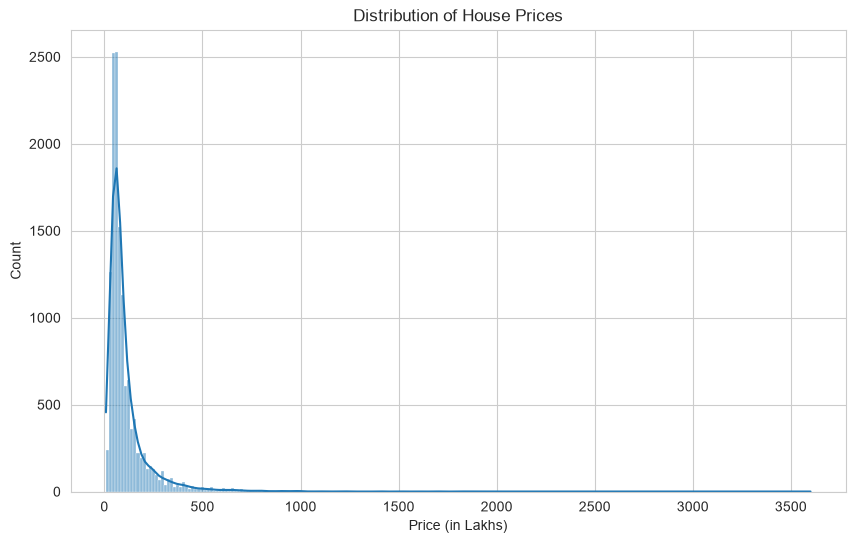

In [24]:
sns.histplot(df4['price'], kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price (in Lakhs)')
plt.ylabel('Count')
plt.show()

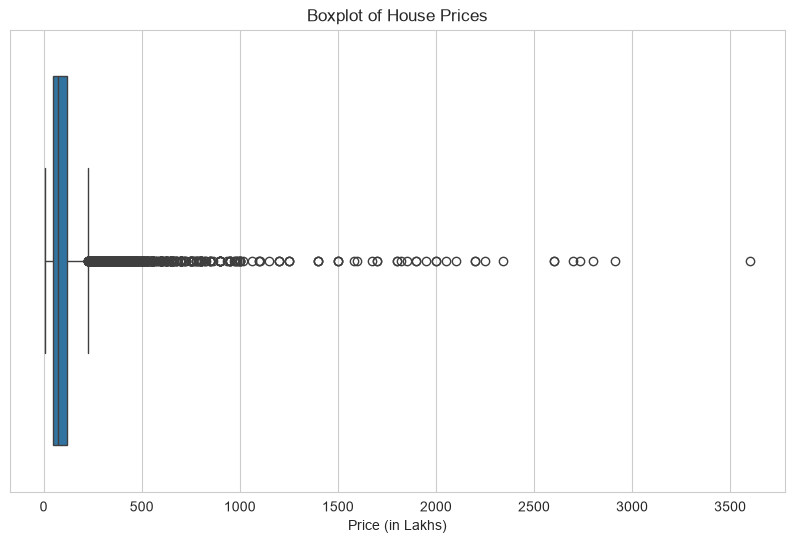

In [25]:
sns.boxplot(x=df4['price'])
plt.title('Boxplot of House Prices')
plt.xlabel('Price (in Lakhs)')
plt.show()

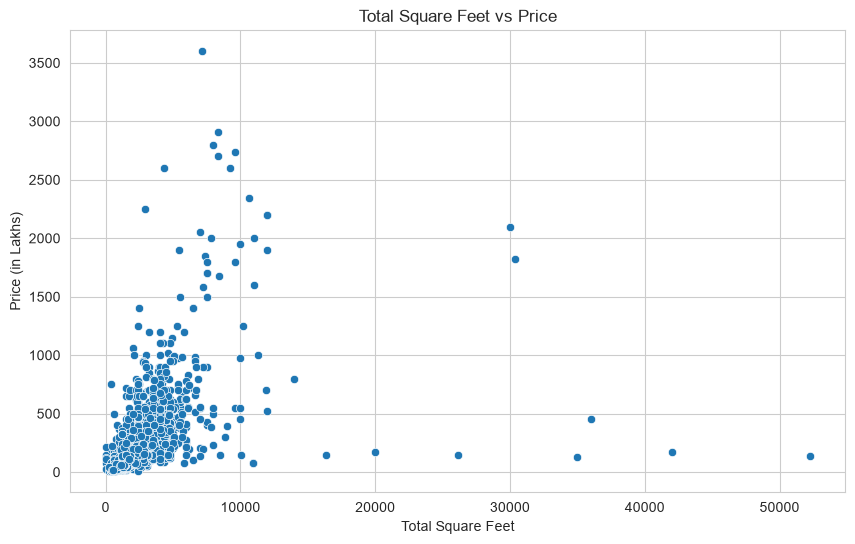

In [26]:
sns.scatterplot(x=df4['total_sqft'], y=df4['price'])
plt.title('Total Square Feet vs Price')
plt.xlabel('Total Square Feet')
plt.ylabel('Price (in Lakhs)')
plt.show()

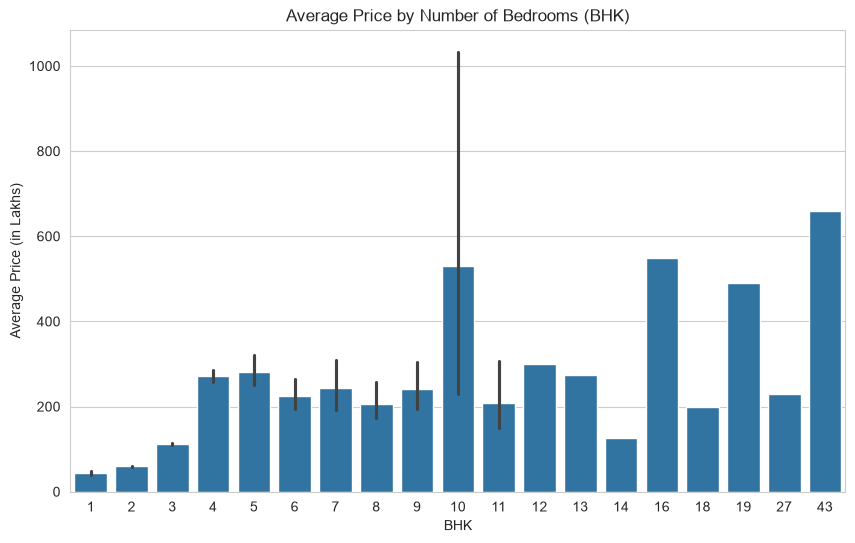

In [27]:
sns.barplot(x='bhk', y='price', data=df4)
plt.title('Average Price by Number of Bedrooms (BHK)')
plt.xlabel('BHK')
plt.ylabel('Average Price (in Lakhs)')
plt.show()

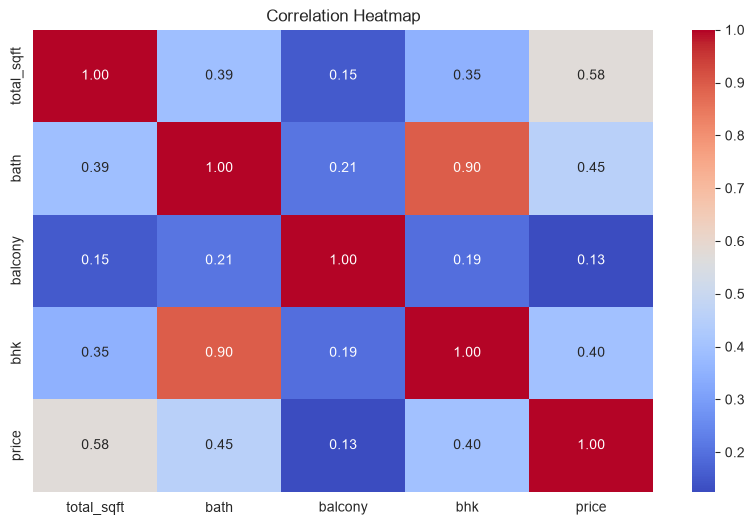

In [28]:
numeric_cols = df4[['total_sqft', 'bath', 'balcony', 'bhk', 'price']]
correlation = numeric_cols.corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [29]:
df4.shape

(13257, 7)

## Phase 5: Feature Engineering & Outlier Removal

In [30]:
df5 = df4.copy()
df5['price_per_sqft'] = df5['price'] * 100000 / df5['total_sqft']
df5.head()

,location,size,total_sqft,bath,balcony,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,1.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,3.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,3.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,1.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,1.0,51.00,2,4250.000000


In [31]:
df5['price_per_sqft'].describe()

count    1.325700e+04
mean     7.912825e+03
std      1.064976e+05
min      2.678298e+02
25%      4.271186e+03
50%      5.438596e+03
75%      7.313318e+03
max      1.200000e+07
Name: price_per_sqft, dtype: float64

In [32]:
df5['price_per_sqft'].describe().apply(lambda x: format(x, 'f'))

count       13257.000000
mean         7912.825441
std        106497.600338
min           267.829813
25%          4271.186441
50%          5438.596491
75%          7313.317937
max      12000000.000000
Name: price_per_sqft, dtype: str

### Outlier Removal Rule 1: Minimum sqft per bedroom (300)

In [33]:
print("Before:", df5.shape)
df6 = df5[~(df5['total_sqft'] / df5['bhk'] < 300)]
print("After:", df6.shape)

Before: (13257, 8)
After: (12513, 8)


### Outlier Removal Rule 2: Remove per-location price_per_sqft outliers

In [34]:
def remove_pps_outliers(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m = np.mean(subdf['price_per_sqft'])
        st = np.std(subdf['price_per_sqft'])
        reduced_df = subdf[(subdf['price_per_sqft'] > (m - st)) & (subdf['price_per_sqft'] <= (m + st))]
        df_out = pd.concat([df_out, reduced_df], ignore_index=True)
    return df_out

print("Before:", df6.shape)
df7 = remove_pps_outliers(df6)
print("After:", df7.shape)

Before: (12513, 8)
After: (9303, 8)


### Outlier Removal Rule 3: Remove BHK price anomalies

In [35]:
def remove_bhk_outliers(df):
    exclude_indices = np.array([])
    for location, location_df in df.groupby('location'):
        bhk_stats = {}
        for bhk, bhk_df in location_df.groupby('bhk'):
            bhk_stats[bhk] = {
                'mean': np.mean(bhk_df['price_per_sqft']),
                'std': np.std(bhk_df['price_per_sqft']),
                'count': bhk_df.shape[0]
            }
        for bhk, bhk_df in location_df.groupby('bhk'):
            stats = bhk_stats.get(bhk - 1)
            if stats and stats['count'] > 5:
                exclude_indices = np.append(exclude_indices, bhk_df[bhk_df['price_per_sqft'] < (stats['mean'])].index.values)
    return df.drop(exclude_indices, axis='index')

print("Before:", df7.shape)
df8 = remove_bhk_outliers(df7)
print("After:", df8.shape)

Before: (9303, 8)
After: (7532, 8)


In [36]:
df8['price_per_sqft'].describe().apply(lambda x: format(x, 'f'))

count     7532.000000
mean      5985.360126
std       2663.738349
min       1250.000000
25%       4424.918167
50%       5448.018528
75%       6666.666667
max      35000.000000
Name: price_per_sqft, dtype: str

In [37]:
df9 = df8.drop(['size', 'price_per_sqft'], axis=1)
df9.head()

,location,total_sqft,bath,balcony,price,bhk
0,Devarabeesana Halli,1672.0,3.0,2.0,150.0,3
1,Devarabeesana Halli,1750.0,3.0,3.0,149.0,3
2,Devarabeesana Halli,1750.0,3.0,2.0,150.0,3
4,Devarachikkanahalli,1250.0,2.0,2.0,40.0,2
5,Devarachikkanahalli,1200.0,2.0,2.0,83.0,2


In [38]:
print("Number of unique locations:", df9['location'].nunique())

Number of unique locations: 765


In [39]:
location_stats = df9['location'].value_counts()
print(location_stats)

location
Whitefield                        246
Sarjapur  Road                    195
Electronic City                   161
Raja Rajeshwari Nagar             140
Uttarahalli                       120
                                 ... 
Whitefield,                         1
Yarandahalli                        1
Yeshwanthpur Industrial Suburb      1
frazertown                          1
manyata park                        1
Name: count, Length: 765, dtype: int64


In [40]:
df9['location'] = df9['location'].apply(lambda x: x.strip())
location_stats = df9['location'].value_counts()

locations_less_than_10 = location_stats[location_stats <= 10]
print("Locations with <=10 houses:", len(locations_less_than_10))

Locations with <=10 houses: 591


In [41]:
df9['location'] = df9['location'].apply(
    lambda x: 'other' if x in locations_less_than_10 else x
)
print("Unique locations after grouping:", df9['location'].nunique())
df9.head()

Unique locations after grouping: 171


,location,total_sqft,bath,balcony,price,bhk
0,other,1672.0,3.0,2.0,150.0,3
1,other,1750.0,3.0,3.0,149.0,3
2,other,1750.0,3.0,2.0,150.0,3
4,Devarachikkanahalli,1250.0,2.0,2.0,40.0,2
5,Devarachikkanahalli,1200.0,2.0,2.0,83.0,2
